# GNN for Airline Fare Prediction

Edge-level regression on an airport route graph. Airports are **nodes**, routes are directed **edges**, and the target is `MARKET_FARE`. A Graph Neural Network aggregates hub-neighborhood context (competition, connectivity) that a simple distance regression cannot capture.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import SAGEConv

sns.set_theme(style='whitegrid')
BLUE = '#4393c3'
print(f"PyTorch {torch.__version__}  |  CUDA: {torch.cuda.is_available()}")

PyTorch 2.12.0.dev20260321+cu128  |  CUDA: True


## 1. Data Loading, Filtering & Aggregation

Load the clean dataset, apply quality filters, then aggregate to route-quarter-carrier level to reduce ~24M ticket rows to ~1–2M unique combinations.

In [2]:
DATA_PATH = '../../data/clean_data/T_DB1B_MARKET_CLEAN.csv'
df = pd.read_csv(DATA_PATH, low_memory=False)
print(f"Raw:  {len(df):,} rows")

# Quality filters:
#   BULK_FARE == 0        — exclude employee/contract fares
#   MARKET_FARE >= 20     — exclude data-entry errors and near-zero fares
#   fare/mile  >= 0.02    — exclude implausibly cheap long-haul tickets
#   MKT_GEO_TYPE == 2     — domestic contiguous US only
df = df[
    (df['BULK_FARE'] == 0) &
    (df['MARKET_FARE'] >= 20) &
    (df['MARKET_FARE'] / df['NONSTOP_MILES'] >= 0.02) &
    (df['MKT_GEO_TYPE'] == 2)
].copy()
print(f"After filters: {len(df):,} rows ({len(df)/32_520_273:.1%} retained)")

# Aggregate: one row per (route, quarter, carrier pair)
# REPORTING_CARRIER included so the enhanced Ridge and MLP can use it as a dummy
agg = (
    df.groupby(['ORIGIN', 'DEST', 'YEAR', 'QUARTER', 'TICKET_CARRIER', 'REPORTING_CARRIER'])
    .agg(
        MARKET_FARE    =('MARKET_FARE',     'mean'),
        MARKET_DISTANCE=('MARKET_DISTANCE', 'mean'),
        NONSTOP_MILES  =('NONSTOP_MILES',   'mean'),
        ORIGIN_LAT     =('ORIGIN_LAT',      'first'),
        ORIGIN_LON     =('ORIGIN_LON',      'first'),
        DEST_LAT       =('DEST_LAT',        'first'),
        DEST_LON       =('DEST_LON',        'first'),
    )
    .reset_index()
)
print(f"Aggregated: {len(agg):,} route-quarter-carrier combinations")
agg.head()

Raw:  25,072,315 rows
After filters: 23,941,756 rows (73.6% retained)
Aggregated: 983,142 route-quarter-carrier combinations


,ORIGIN,DEST,YEAR,QUARTER,TICKET_CARRIER,REPORTING_CARRIER,MARKET_FARE,MARKET_DISTANCE,NONSTOP_MILES,ORIGIN_LAT,ORIGIN_LON,DEST_LAT,DEST_LON
0,ABE,ABI,2024,3,AA,MQ,430.500000,1575.000000,1458.0,40.6521,-75.440804,32.411301,-99.681900
1,ABE,ABQ,2024,3,99,G7,283.715000,1773.000000,1738.0,40.6521,-75.440804,35.040199,-106.609001
2,ABE,ABQ,2024,3,AA,OH,304.250000,1986.000000,1738.0,40.6521,-75.440804,35.040199,-106.609001
3,ABE,ABQ,2024,3,DL,9E,436.866667,2029.777778,1738.0,40.6521,-75.440804,35.040199,-106.609001
4,ABE,ABQ,2024,3,DL,DL,384.895000,1961.000000,1738.0,40.6521,-75.440804,35.040199,-106.609001


## 2. Feature Engineering

**Node features** (per airport, computed from train set only to avoid leakage): lat, lon, out-degree, mean departing fare.

**Edge features** (per route-quarter-carrier): log distance, cyclic quarter encoding (sin/cos so Q4→Q1 wraps correctly), carrier as a learned embedding.

**Target**: `log(MARKET_FARE)` — log-transform stabilises MSE training on the right-skewed fare distribution.

In [3]:
# ── Temporal split masks ──────────────────────────────────────────────────────
train_mask = (agg['YEAR'] == 2024)                               # Q3 + Q4 2024
val_mask   = (agg['YEAR'] == 2025) & (agg['QUARTER'] == 1)      # Q1 2025
test_mask  = (agg['YEAR'] == 2025) & (agg['QUARTER'] == 2)      # Q2 2025

train_df = agg[train_mask]
print(f"Train: {train_mask.sum():,}  Val: {val_mask.sum():,}  Test: {test_mask.sum():,}")

# ── Airport index ─────────────────────────────────────────────────────────────
all_airports = pd.unique(pd.concat([agg['ORIGIN'], agg['DEST']]))
airport_to_idx = {a: i for i, a in enumerate(all_airports)}
num_airports = len(all_airports)
print(f"Unique airports: {num_airports}")

# ── Node features (fit on train only) ─────────────────────────────────────────
node_stats = (
    train_df.groupby('ORIGIN')
    .agg(degree   =('DEST',        'nunique'),
         mean_fare =('MARKET_FARE', 'mean'),
         lat       =('ORIGIN_LAT',  'first'),
         lon       =('ORIGIN_LON',  'first'))
    .reindex(all_airports, fill_value=0)
)
node_scaler = StandardScaler()
node_feat_cols = ['lat', 'lon', 'degree', 'mean_fare']
node_features = torch.tensor(
    node_scaler.fit_transform(node_stats[node_feat_cols].values),
    dtype=torch.float
)
print(f"Node feature matrix: {node_features.shape}")

# ── Carrier encoding ──────────────────────────────────────────────────────────
carriers = agg['TICKET_CARRIER'].unique()
carrier_to_idx = {c: i for i, c in enumerate(carriers)}
num_carriers = len(carriers)
print(f"Unique carriers: {num_carriers}")

# ── Edge features ─────────────────────────────────────────────────────────────
agg['log_distance'] = np.log1p(agg['MARKET_DISTANCE'])
agg['sin_q'] = np.sin(2 * np.pi * (agg['QUARTER'] - 1) / 4)
agg['cos_q'] = np.cos(2 * np.pi * (agg['QUARTER'] - 1) / 4)
agg['carrier_idx'] = agg['TICKET_CARRIER'].map(carrier_to_idx)
agg['log_fare'] = np.log(agg['MARKET_FARE'])
agg['src_idx'] = agg['ORIGIN'].map(airport_to_idx)
agg['dst_idx'] = agg['DEST'].map(airport_to_idx)

edge_feat_cols = ['log_distance', 'sin_q', 'cos_q']
edge_scaler = StandardScaler()
edge_scaler.fit(agg.loc[train_mask, edge_feat_cols].values)   # fit on train only
edge_feats = edge_scaler.transform(agg[edge_feat_cols].values)

print(f"Edge feature matrix: {edge_feats.shape}")

Train: 493,882  Val: 232,190  Test: 257,070
Unique airports: 400
Node feature matrix: torch.Size([400, 4])
Unique carriers: 39
Edge feature matrix: (983142, 3)


## 3. Graph Construction (PyTorch Geometric)

One global graph — all quarters share the same node set (airports). Quarter and carrier are encoded as edge features, so a single `Data` object holds the full dataset with per-edge targets and split masks.

In [4]:
edge_index  = torch.tensor(agg[['src_idx', 'dst_idx']].values.T, dtype=torch.long)
edge_attr   = torch.tensor(edge_feats, dtype=torch.float)
carrier_ids = torch.tensor(agg['carrier_idx'].values, dtype=torch.long)
y           = torch.tensor(agg['log_fare'].values, dtype=torch.float)

train_idx = torch.where(torch.tensor(train_mask.values))[0]
val_idx   = torch.where(torch.tensor(val_mask.values))[0]
test_idx  = torch.where(torch.tensor(test_mask.values))[0]

data = Data(x=node_features, edge_index=edge_index, edge_attr=edge_attr, y=y)
data.carrier_ids = carrier_ids

print(f"Graph — nodes: {data.num_nodes:,}  |  edges: {data.num_edges:,}")
print(f"Node feat dim: {data.num_node_features}  |  Edge feat dim: {data.num_edge_features}")
print(f"Train edges: {len(train_idx):,}  Val: {len(val_idx):,}  Test: {len(test_idx):,}")

Graph — nodes: 400  |  edges: 983,142
Node feat dim: 4  |  Edge feat dim: 3
Train edges: 493,882  Val: 232,190  Test: 257,070


## 4. Baseline — Enhanced Ridge Regression

Ridge regression with a rich fixed-effects feature set: log-distance, cyclic quarter, year, one-hot ORIGIN (400 airports), DEST (400 airports), TICKET_CARRIER, and REPORTING_CARRIER. This is a strong benchmark — it captures most route-level fixed effects that a simple linear model can recover. The GNN must beat this to demonstrate that graph neighborhood context adds genuine value beyond what dummy variables already encode.

> **Note:** `MKT_GEO_TYPE` is excluded — it is filtered to the constant value `2` before aggregation, so it carries zero information.

In [5]:
def eval_dollars(y_true_log, y_pred_log):
    """Return (RMSE $, MAE $, R² on log scale)."""
    y_true = np.exp(y_true_log)
    y_pred = np.exp(y_pred_log)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = np.mean(np.abs(y_true - y_pred))
    r2   = r2_score(y_true_log, y_pred_log)
    return rmse, mae, r2

# Features: numeric (log_distance, sin_q, cos_q, YEAR) +
#           one-hot dummies (TICKET_CARRIER, REPORTING_CARRIER, ORIGIN, DEST)
# ORIGIN and DEST add ~800 binary columns — Ridge regularisation handles the high dimensionality
X_cols = ['log_distance', 'sin_q', 'cos_q', 'YEAR',
          'TICKET_CARRIER', 'REPORTING_CARRIER', 'ORIGIN', 'DEST']
X = agg[X_cols].copy()
y_np = agg['log_fare'].values

X_train, y_train = X[train_mask], y_np[train_mask]
X_val,   y_val   = X[val_mask],   y_np[val_mask]
X_test,  y_test  = X[test_mask],  y_np[test_mask]

preprocessor = ColumnTransformer([
    ('num', StandardScaler(),
     ['log_distance', 'sin_q', 'cos_q', 'YEAR']),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False),
     ['TICKET_CARRIER', 'REPORTING_CARRIER', 'ORIGIN', 'DEST']),
])
baseline = Pipeline([('pre', preprocessor), ('reg', Ridge())])
baseline.fit(X_train, y_train)

bl_val  = baseline.predict(X_val)
bl_test = baseline.predict(X_test)

rmse_v, mae_v, r2_v = eval_dollars(y_val,  bl_val)
rmse_t, mae_t, r2_t = eval_dollars(y_test, bl_test)
print(f"Ridge+  Val  — RMSE: ${rmse_v:.1f}  MAE: ${mae_v:.1f}  R²: {r2_v:.3f}")
print(f"Ridge+  Test — RMSE: ${rmse_t:.1f}  MAE: ${mae_t:.1f}  R²: {r2_t:.3f}")

Ridge+  Val  — RMSE: $81.3  MAE: $61.2  R²: 0.304
Ridge+  Test — RMSE: $78.6  MAE: $58.2  R²: 0.324


## 5. MLP — Multilayer Perceptron

Same feature set as the enhanced Ridge (same `ColumnTransformer` preprocessing), but non-linear. A 3-hidden-layer feedforward network with BatchNorm and Dropout. Isolates whether non-linear combinations of route fixed effects help — before introducing graph structure.

Architecture: `Input (~870) → 256 → 128 → 64 → 1`

MLP input dim: 850
MLP(
  (net): Sequential(
    (0): Linear(in_features=850, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=64, out_features=1, bias=True)
  )
)

Trainable parameters: 259,969
Epoch  10  train: 0.3777  val: 0.0741
Epoch  20  train: 0.2597  val: 0.0810
Early stop at epoch 21

Best MLP val loss: 0.0733


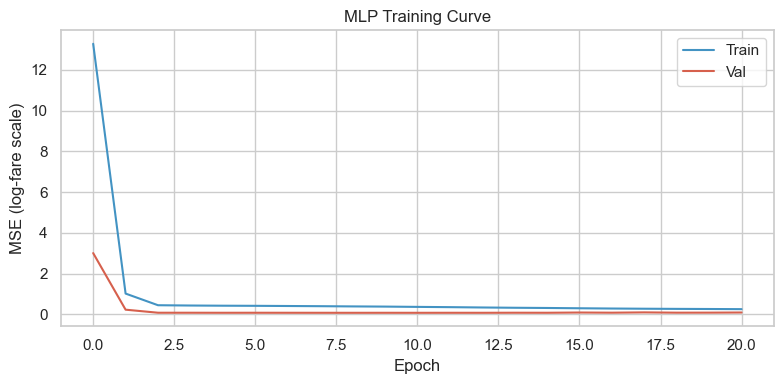

MLP     Val  — RMSE: $81.2  MAE: $60.3  R²: 0.333
MLP     Test — RMSE: $79.2  MAE: $59.4  R²: 0.312


In [6]:
# ── Preprocess with the same pipeline as Ridge ────────────────────────────────
# Reuse the fitted preprocessor so features are identical
X_train_np = preprocessor.transform(X_train).astype(np.float32)
X_val_np   = preprocessor.transform(X_val).astype(np.float32)
X_test_np  = preprocessor.transform(X_test).astype(np.float32)
input_dim  = X_train_np.shape[1]
print(f"MLP input dim: {input_dim}")

X_tr_t  = torch.tensor(X_train_np)
X_va_t  = torch.tensor(X_val_np)
X_te_t  = torch.tensor(X_test_np)
y_tr_t  = torch.tensor(y_train.astype(np.float32))
y_va_t  = torch.tensor(y_val.astype(np.float32))

# ── Model ─────────────────────────────────────────────────────────────────────
class MLP(nn.Module):
    def __init__(self, in_dim, hidden=(256, 128, 64), dropout=0.2):
        super().__init__()
        layers = []
        prev = in_dim
        for h in hidden:
            layers += [nn.Linear(prev, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)

mlp_device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
mlp_model  = MLP(input_dim).to(mlp_device)
n_params   = sum(p.numel() for p in mlp_model.parameters() if p.requires_grad)
print(mlp_model)
print(f"\nTrainable parameters: {n_params:,}")

# ── Training ──────────────────────────────────────────────────────────────────
BATCH_SIZE = 4096
optimizer  = torch.optim.Adam(mlp_model.parameters(), lr=1e-3, weight_decay=1e-5)
dataset    = torch.utils.data.TensorDataset(X_tr_t, y_tr_t)
loader     = torch.utils.data.DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

X_va_d = X_va_t.to(mlp_device)
y_va_d = y_va_t.to(mlp_device)

mlp_train_losses, mlp_val_losses = [], []
best_mlp_val, best_mlp_state, mlp_patience_ctr = float('inf'), None, 0
PATIENCE = 10

for epoch in range(1, 101):
    mlp_model.train()
    epoch_loss = 0.0
    for xb, yb in loader:
        xb, yb = xb.to(mlp_device), yb.to(mlp_device)
        optimizer.zero_grad()
        loss = F.mse_loss(mlp_model(xb), yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(xb)
    epoch_loss /= len(dataset)

    mlp_model.eval()
    with torch.no_grad():
        val_loss = F.mse_loss(mlp_model(X_va_d), y_va_d).item()

    mlp_train_losses.append(epoch_loss)
    mlp_val_losses.append(val_loss)

    if val_loss < best_mlp_val:
        best_mlp_val   = val_loss
        best_mlp_state = {k: v.clone() for k, v in mlp_model.state_dict().items()}
        mlp_patience_ctr = 0
    else:
        mlp_patience_ctr += 1
        if mlp_patience_ctr >= PATIENCE:
            print(f"Early stop at epoch {epoch}")
            break

    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d}  train: {epoch_loss:.4f}  val: {val_loss:.4f}")

mlp_model.load_state_dict(best_mlp_state)
print(f"\nBest MLP val loss: {best_mlp_val:.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(mlp_train_losses, label='Train', color='#4393c3')
ax.plot(mlp_val_losses,   label='Val',   color='#d6604d')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE (log-fare scale)')
ax.set_title('MLP Training Curve'); ax.legend()
plt.tight_layout(); plt.show()

# ── Eval ──────────────────────────────────────────────────────────────────────
mlp_model.eval()
with torch.no_grad():
    mlp_val_pred  = mlp_model(X_va_t.to(mlp_device)).cpu().numpy()
    mlp_test_pred = mlp_model(X_te_t.to(mlp_device)).cpu().numpy()

mlp_rmse_v, mlp_mae_v, mlp_r2_v = eval_dollars(y_val,  mlp_val_pred)
mlp_rmse_t, mlp_mae_t, mlp_r2_t = eval_dollars(y_test, mlp_test_pred)
print(f"MLP     Val  — RMSE: ${mlp_rmse_v:.1f}  MAE: ${mlp_mae_v:.1f}  R²: {mlp_r2_v:.3f}")
print(f"MLP     Test — RMSE: ${mlp_rmse_t:.1f}  MAE: ${mlp_mae_t:.1f}  R²: {mlp_r2_t:.3f}")

## 6. GNN Model — EdgeGNN

Architecture:
1. **NodeEncoder**: linear projection of node features → hidden dimension
2. **2× SAGEConv**: message-passing layers that aggregate hub-neighborhood context
3. **EdgeDecoder**: MLP on `[src_emb ‖ dst_emb ‖ edge_feats ‖ carrier_emb]` → predicted log-fare

Carrier is a learned `nn.Embedding` (8-dim) rather than one-hot, which handles rare carriers and captures latent pricing similarities. Unlike Ridge and MLP, the GNN sees the full graph topology — each airport's embedding reflects its hub connections, competition, and pricing neighbourhood.

In [7]:
class EdgeGNN(nn.Module):
    def __init__(self, node_feat_dim, edge_feat_dim, num_carriers,
                 hidden_dim=128, carrier_emb_dim=8, dropout=0.1):
        super().__init__()
        self.carrier_emb = nn.Embedding(num_carriers, carrier_emb_dim)
        self.node_enc    = nn.Linear(node_feat_dim, hidden_dim)
        self.conv1       = SAGEConv(hidden_dim, hidden_dim)
        self.conv2       = SAGEConv(hidden_dim, hidden_dim)

        dec_in = 2 * hidden_dim + edge_feat_dim + carrier_emb_dim
        self.decoder = nn.Sequential(
            nn.Linear(dec_in, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
        )

    def forward(self, x, edge_index, edge_attr, carrier_ids):
        h = F.relu(self.node_enc(x))
        h = F.relu(self.conv1(h, edge_index))
        h = F.relu(self.conv2(h, edge_index))

        src, dst = edge_index
        carrier_e = self.carrier_emb(carrier_ids)
        edge_in   = torch.cat([h[src], h[dst], edge_attr, carrier_e], dim=-1)
        return self.decoder(edge_in).squeeze(-1)


model = EdgeGNN(
    node_feat_dim  = node_features.shape[1],
    edge_feat_dim  = edge_attr.shape[1],
    num_carriers   = num_carriers,
    hidden_dim     = 128,
)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f"\nTrainable parameters: {n_params:,}")

EdgeGNN(
  (carrier_emb): Embedding(39, 8)
  (node_enc): Linear(in_features=4, out_features=128, bias=True)
  (conv1): SAGEConv(128, 128, aggr=mean)
  (conv2): SAGEConv(128, 128, aggr=mean)
  (decoder): Sequential(
    (0): Linear(in_features=267, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Linear(in_features=64, out_features=1, bias=True)
  )
)

Trainable parameters: 109,369


## 7. GNN Training

Full-graph training (all edges fit in memory after aggregation). Adam with weight decay, MSE loss on log-fare, early stopping on validation loss with patience=10.

Training on: cuda
Epoch  10  train: 16.3162  val: 11.5031
Epoch  20  train: 0.1998  val: 0.5124
Early stop at epoch 29

Best val loss: 0.1275


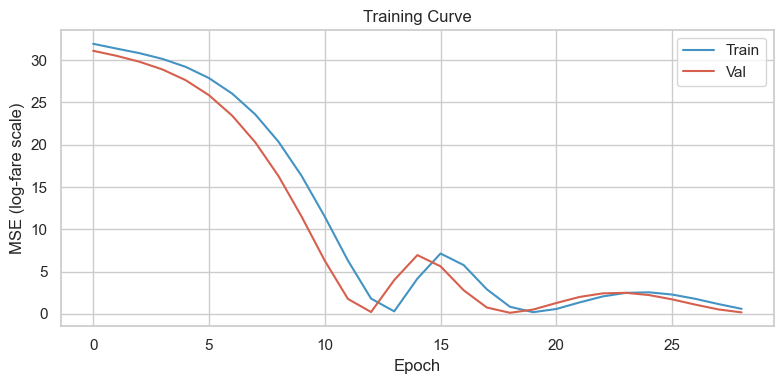

In [8]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Training on: {device}")

model = EdgeGNN(
    node_feat_dim = node_features.shape[1],
    edge_feat_dim = edge_attr.shape[1],
    num_carriers  = num_carriers,
    hidden_dim    = 128,
).to(device)

x_d    = data.x.to(device)
ei_d   = data.edge_index.to(device)
ea_d   = data.edge_attr.to(device)
cids_d = data.carrier_ids.to(device)
y_d    = data.y.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

train_losses, val_losses = [], []
best_val_loss = float('inf')
patience, patience_ctr = 10, 0
best_state = None

for epoch in range(1, 101):
    model.train()
    optimizer.zero_grad()
    pred = model(x_d, ei_d, ea_d, cids_d)
    loss = F.mse_loss(pred[train_idx], y_d[train_idx])
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        pred_all = model(x_d, ei_d, ea_d, cids_d)
        val_loss = F.mse_loss(pred_all[val_idx], y_d[val_idx]).item()

    train_losses.append(loss.item())
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
        patience_ctr = 0
    else:
        patience_ctr += 1
        if patience_ctr >= patience:
            print(f"Early stop at epoch {epoch}")
            break

    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d}  train: {loss.item():.4f}  val: {val_loss:.4f}")

model.load_state_dict(best_state)
print(f"\nBest val loss: {best_val_loss:.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(train_losses, label='Train', color='#4393c3')
ax.plot(val_losses,   label='Val',   color='#d6604d')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE (log-fare scale)')
ax.set_title('Training Curve')
ax.legend()
plt.tight_layout()
plt.show()

## 8. Model Comparison

All three models evaluated on the held-out test set (2025 Q2). Metrics in original dollar scale for interpretability. Expected ordering: GNN ≥ MLP ≥ Ridge+.

Model        Split   RMSE ($)   MAE ($)      R²
-------------------------------------------------------------
Ridge+       Val        81.3      61.2   0.304
Ridge+       Test       78.6      58.2   0.324
-------------------------------------------------------------
MLP          Val        81.2      60.3   0.333
MLP          Test       79.2      59.4   0.312
-------------------------------------------------------------
GNN          Val       109.6      80.5  -0.161
GNN          Test      119.1      83.3  -0.282
-------------------------------------------------------------


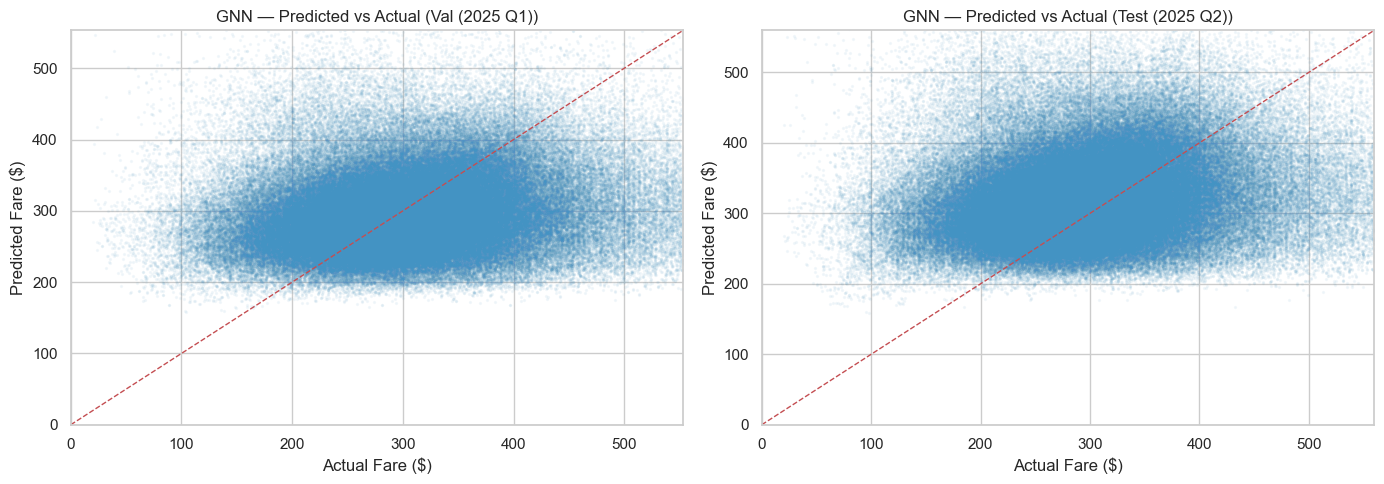

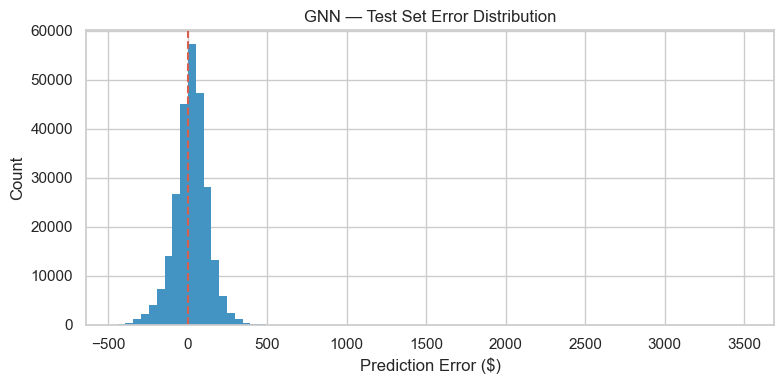


GNN  median absolute error (test): $64.6
MLP  median absolute error (test): $45.4
Ridge+ median absolute error (test): $43.4


In [9]:
model.eval()
with torch.no_grad():
    pred_log = model(x_d, ei_d, ea_d, cids_d).cpu().numpy()

y_np_all = y_d.cpu().numpy()

gnn_val  = eval_dollars(y_np_all[val_idx],  pred_log[val_idx])
gnn_test = eval_dollars(y_np_all[test_idx], pred_log[test_idx])

# ── Summary Table ─────────────────────────────────────────────────────────────
print("=" * 61)
print(f"{'Model':<12} {'Split':<6} {'RMSE ($)':>9} {'MAE ($)':>9} {'R²':>7}")
print("-" * 61)
for label, rv, rt in [
    ('Ridge+',  (rmse_v,     mae_v,     r2_v),     (rmse_t,     mae_t,     r2_t)),
    ('MLP',     (mlp_rmse_v, mlp_mae_v, mlp_r2_v), (mlp_rmse_t, mlp_mae_t, mlp_r2_t)),
    ('GNN',     gnn_val,                            gnn_test),
]:
    rmse_rv, mae_rv, r2_rv = rv
    rmse_rt, mae_rt, r2_rt = rt
    print(f"{label:<12} {'Val':<6} {rmse_rv:>8.1f}  {mae_rv:>8.1f}  {r2_rv:>6.3f}")
    print(f"{label:<12} {'Test':<6} {rmse_rt:>8.1f}  {mae_rt:>8.1f}  {r2_rt:>6.3f}")
    print("-" * 61)

# ── GNN Predicted vs Actual ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, idx, label in [(axes[0], val_idx, 'Val (2025 Q1)'), (axes[1], test_idx, 'Test (2025 Q2)')]:
    y_true_d = np.exp(y_np_all[idx])
    y_pred_d = np.exp(pred_log[idx])
    ax.scatter(y_true_d, y_pred_d, alpha=0.05, s=2, color=BLUE)
    lim = np.percentile(np.concatenate([y_true_d, y_pred_d]), 99)
    ax.plot([0, lim], [0, lim], 'r--', linewidth=1)
    ax.set_xlim(0, lim); ax.set_ylim(0, lim)
    ax.set_xlabel('Actual Fare ($)')
    ax.set_ylabel('Predicted Fare ($)')
    ax.set_title(f'GNN — Predicted vs Actual ({label})')
plt.tight_layout()
plt.show()

# ── GNN Error Distribution ────────────────────────────────────────────────────
errors = np.exp(pred_log[test_idx]) - np.exp(y_np_all[test_idx])
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(errors, bins=80, color=BLUE, edgecolor='none')
ax.axvline(0, color='#d6604d', linestyle='--', linewidth=1.5)
ax.set_xlabel('Prediction Error ($)')
ax.set_ylabel('Count')
ax.set_title('GNN — Test Set Error Distribution')
plt.tight_layout()
plt.show()

print(f"\nGNN  median absolute error (test): ${np.median(np.abs(errors)):.1f}")
print(f"MLP  median absolute error (test): ${np.median(np.abs(np.exp(mlp_test_pred) - np.exp(y_test))):.1f}")
print(f"Ridge+ median absolute error (test): ${np.median(np.abs(np.exp(bl_test) - np.exp(y_test))):.1f}")